<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 11.2</h1>

The aim of this exercise is to extend the neural network regression to the non-linear third-order polynomial

$$
f(x)=4-3x-2x^2+3x^3,
$$

defined in the interval $x\in[-1,1]$. We will investigate how the choice of the neural network architecture and training strategy, including the number of layers, number of neurons, activation function, optimizer, and loss function, affects the quality of the fit and the ability of the model to generalize to newly generated data.

In particular, we will compare the predictions of the trained network with test data both inside and outside the original training interval. This will allow us to investigate the relationship between model complexity, goodness of fit on the training data, and predictive performance on unseen data, with particular attention to the difference between interpolation within the training range and extrapolation outside it.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

import csv

I0000 00:00:1790006051.888604   86026 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790006058.968168   86026 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790006064.822744   86026 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
#Reproducibility
np.random.seed(0)
tf.random.set_seed(0)

In [4]:
def f(x):
    return 4 - 3*x - 2*x**2 + 3*x**3

In [5]:
def generate_data_poly(N_train, N_valid, sigma):
    
    #Generate the datasets

    x_train = np.random.uniform(-1, 1, N_train)

    x_valid = np.random.uniform(-1, 1, N_valid)
    x_valid.sort()

    #True function
    y_target = f(x_valid)

    #Noisy data
    y_train = np.random.normal(f(x_train), sigma)
    y_valid = np.random.normal(f(x_valid), sigma)

    return x_train, y_train, x_valid, y_valid, y_target

In [6]:
def build_model_poly(n_neurons = 10, activation="tanh", optimizer="adam", loss="mse"):

    model = Sequential()

    model.add(Input(shape=(1,)))

    model.add(Dense(n_neurons, activation=activation))

    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss=loss, metrics=["mse"])

    return model

In [7]:
def run_experiment_poly(model, x_train, y_train, x_valid, y_valid, y_target, N_epochs, batch_size):

    # The algorithm stops when it doesn't get better after 100 epochs

    early_stop = EarlyStopping(monitor="val_loss", patience=100, restore_best_weights=True)

    #Train the model

    history = model.fit(x=x_train, y=y_train, batch_size=batch_size, epochs=N_epochs, shuffle=True, validation_data=(x_valid, y_valid), callbacks=[early_stop], verbose=0)
    
    #Calculate predictions

    y_pred_train = model(x_train, training=False).numpy().flatten()

    y_pred_valid = model(x_valid, training=False).numpy().flatten()

    #Calculate MSE

    mse_train = np.mean((y_pred_train - y_train)**2)

    mse_valid = np.mean((y_pred_valid - y_valid)**2)

    mse_true = np.mean((y_pred_valid - y_target)**2)

    #Return results

    results = {"MSE_train": mse_train, "MSE_valid": mse_valid, "MSE_true": mse_true}

    return model, history, results

### Final choice of the noise parameter

For the comparison of the different NN architectures, we set $\sigma=0$. This allows us to study the effect of the number of neurons, the number of epochs, the activation function, and the optimizer without the additional complication introduced by noise. In this case the MSE directly measures how well the NN is able to approximate the underlying function.

Once the best NN configuration has been identified, we introduce a realistic amount of noise, choosing a non-zero value of $\sigma$. This final test allows us to study the predictive ability of the network in a more realistic situation and to investigate the difference between the error on noisy validation data and the error with respect to the true function.

In particular, with $\sigma>0$ we expect, in general,

$$
MSE_{\mathrm{valid}} \neq MSE_{\mathrm{true}},
$$

since the validation data contain a random noise contribution, while $MSE_{\mathrm{true}}$ is computed with respect to the underlying noise-free function.

In [8]:
N_train_poly = 500
N_valid_poly = 50
sigma_poly = 0.0

N_epochs_poly = 2000
batch_size_poly = 32

n_neurons = 10
activation = "tanh"
optimizer = "adam"
loss = "mse"

In [9]:
x_train_poly, y_train_poly, x_valid_poly, y_valid_poly, y_target_poly = generate_data_poly(N_train_poly, N_valid_poly, sigma_poly)

In [10]:
model_poly = build_model_poly(n_neurons=10, activation="tanh", optimizer="adam", loss="mse")
model_poly.summary()

E0000 00:00:1790006067.294741   86026 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model_poly, history_poly, results_poly = run_experiment_poly(model_poly, x_train_poly, y_train_poly, x_valid_poly, y_valid_poly, y_target_poly, N_epochs_poly, batch_size_poly)

In [12]:
print("MSE train :", results_poly["MSE_train"])
print("MSE valid :", results_poly["MSE_valid"])
print("MSE true  :", results_poly["MSE_true"])

MSE train : 0.0005908881653527404
MSE valid : 0.0008032677702997971
MSE true  : 0.0008032677702997971


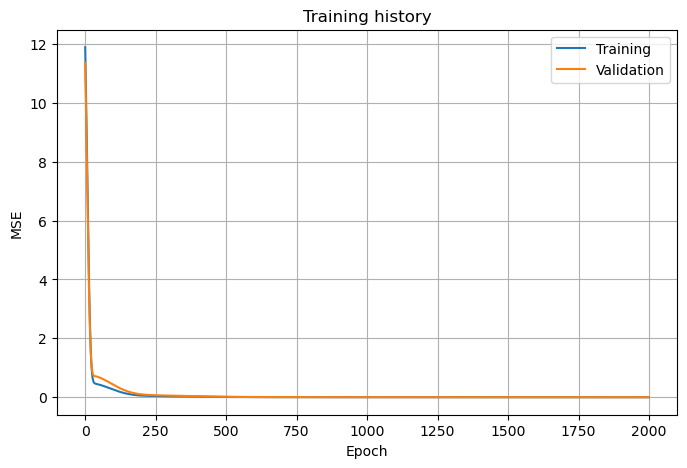

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history_poly.history["loss"], label="Training")
plt.plot(history_poly.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training history")

plt.grid(True)
plt.legend()

plt.show()

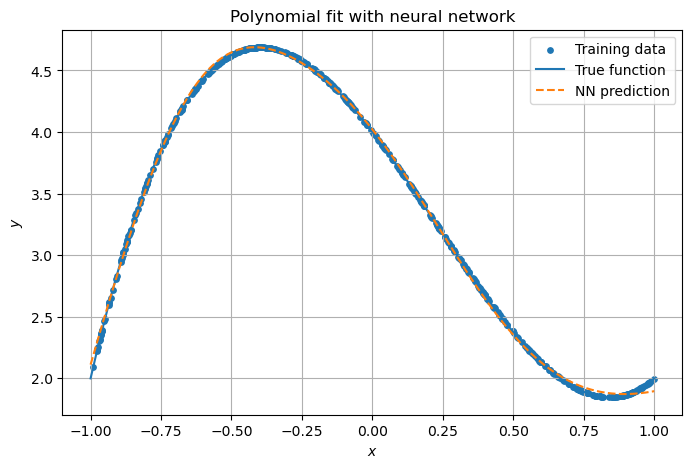

In [14]:
x_plot = np.linspace(-1, 1, 500)

y_true_plot = f(x_plot)

y_pred_plot = model_poly(x_plot, training=False).numpy().flatten()

plt.figure(figsize=(8, 5))

plt.scatter( x_train_poly, y_train_poly, s=15, label="Training data")

plt.plot( x_plot, y_true_plot, label="True function")

plt.plot( x_plot, y_pred_plot, "--", label="NN prediction")

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Polynomial fit with neural network")

plt.grid(True)
plt.legend()

plt.show()

With N_epochs 2000 the Dense(10, than) -> Dense(1) network is sufficient to represent the polynomial well provided you have a sufficient number of epochs \
MSE train : 0.00020637074831965713 \
MSE valid : 0.00029567505762960916 \
MSE true  : 0.00029567505762960916 

### Number of neurons

In [15]:
neurons_values = [2, 5, 10, 20, 50]

In [16]:
neuron_results = []

for n_neurons in neurons_values:

    model_poly = build_model_poly(n_neurons=n_neurons, activation=activation, optimizer=optimizer)

    model_poly, history_poly, results_poly = run_experiment_poly(model_poly, x_train_poly, y_train_poly, x_valid_poly, y_valid_poly, y_target_poly, N_epochs_poly, batch_size_poly)

    neuron_results.append({"n_neurons": n_neurons, "MSE_train": results_poly["MSE_train"], "MSE_valid": results_poly["MSE_valid"], "MSE_true": results_poly["MSE_true"]})

    print(
        f"Neurons: {n_neurons:2d} | "
        f"MSE train: {results_poly['MSE_train']:.6e} | "
        f"MSE valid: {results_poly['MSE_valid']:.6e} | "
        f"MSE true: {results_poly['MSE_true']:.6e}"
    )

Neurons:  2 | MSE train: 1.409173e-03 | MSE valid: 7.574012e-04 | MSE true: 7.574012e-04
Neurons:  5 | MSE train: 3.527727e-04 | MSE valid: 4.225576e-04 | MSE true: 4.225576e-04
Neurons: 10 | MSE train: 9.638003e-05 | MSE valid: 8.622629e-05 | MSE true: 8.622629e-05
Neurons: 20 | MSE train: 1.188961e-04 | MSE valid: 1.742520e-04 | MSE true: 1.742520e-04
Neurons: 50 | MSE train: 2.294106e-04 | MSE valid: 3.455825e-04 | MSE true: 3.455825e-04


In [17]:
neuron_data = pd.DataFrame(neuron_results)

neuron_data

,n_neurons,MSE_train,MSE_valid,MSE_true
0,2,0.001409,0.000757,0.000757
1,5,0.000353,0.000423,0.000423
2,10,0.000096,0.000086,0.000086
3,20,0.000119,0.000174,0.000174
4,50,0.000229,0.000346,0.000346


In [18]:
def plot_mse(data, x_column, xlabel, log_x=False, log_y=False):

    plt.figure(figsize=(8, 5))

    plt.plot(data[x_column], data["MSE_train"], "o-", label="Training MSE")

    plt.plot(data[x_column], data["MSE_valid"], "o-", label="Validation MSE")

    plt.plot(data[x_column], data["MSE_true"], "o-", label="True function MSE")

    plt.xlabel(xlabel)
    plt.ylabel("MSE")
    plt.title("MSE vs " + xlabel)

    if log_x:
        plt.xscale("log")

    if log_y:
        plt.yscale("log")

    plt.grid(True)
    plt.legend()

    plt.show()

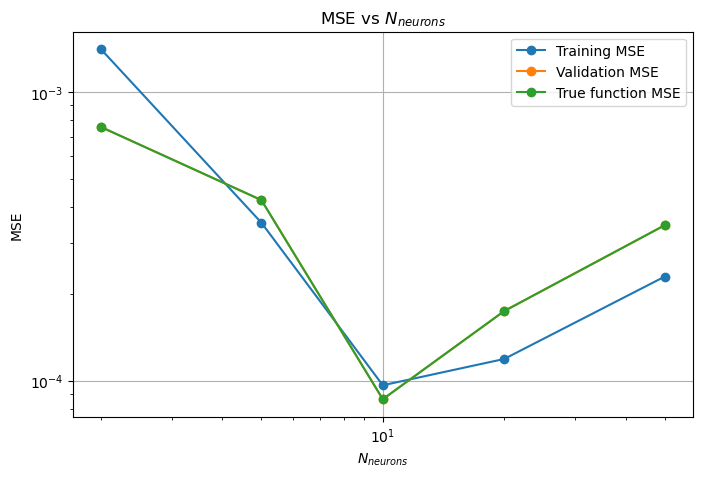

In [19]:
plot_mse(neuron_data, "n_neurons", "$N_{neurons}$", log_x=True, log_y=True)

**Figure 1.** Comparison of the MSE evaluated on the training set, the validation set, and with respect to the true function for neural networks with an increasing number of neurons in the hidden layer. The model is trained using $N_{\mathrm{train}}=500$ data points with no added noise, for $N_{\mathrm{epochs}}=2000$ epochs, using a hyperbolic tangent activation function, the Adam optimizer, and the MSE loss function. Increasing the number of neurons from 2 to 10 significantly improves the quality of the fit, with the validation and true-function MSE decreasing from $7.57\times10^{-4}$ for 2 neurons to $8.62\times10^{-5}$ for 10 neurons. For larger networks, the MSE increases again, reaching $1.74\times10^{-4}$ with 20 neurons and $3.46\times10^{-4}$ with 50 neurons. This indicates that, for the chosen training conditions, increasing the network size beyond 10 neurons does not improve the approximation of the polynomial. The network with 10 neurons therefore provides the lowest MSE on both the validation set and with respect to the true function.

In [20]:
activation_values = ["linear", "relu", "sigmoid", "tanh"]
n_neurons = 10

In [21]:
activation_results = []

for activation in activation_values:

    model_poly = build_model_poly(n_neurons=n_neurons, activation=activation, optimizer=optimizer)

    model_poly, history_poly, results_poly = run_experiment_poly(model_poly, x_train_poly, y_train_poly, x_valid_poly, y_valid_poly, y_target_poly, N_epochs_poly, batch_size_poly)

    activation_results.append({"activation": activation, "MSE_train": results_poly["MSE_train"], "MSE_valid": results_poly["MSE_valid"], "MSE_true": results_poly["MSE_true"]})

    print(
        f"activation: {activation:7s} | "
        f"MSE train: {results_poly['MSE_train']:.6e} | "
        f"MSE valid: {results_poly['MSE_valid']:.6e} | "
        f"MSE true: {results_poly['MSE_true']:.6e}"
    )

activation: linear  | MSE train: 5.612731e-01 | MSE valid: 8.411587e-01 | MSE true: 8.411587e-01
activation: relu    | MSE train: 1.961465e-02 | MSE valid: 2.512548e-02 | MSE true: 2.512548e-02
activation: sigmoid | MSE train: 5.640574e-04 | MSE valid: 5.070260e-04 | MSE true: 5.070260e-04
activation: tanh    | MSE train: 2.374785e-04 | MSE valid: 3.021195e-04 | MSE true: 3.021195e-04


In [22]:
activation_data = pd.DataFrame(activation_results)

activation_data

,activation,MSE_train,MSE_valid,MSE_true
0,linear,0.561273,0.841159,0.841159
1,relu,0.019615,0.025125,0.025125
2,sigmoid,0.000564,0.000507,0.000507
3,tanh,0.000237,0.000302,0.000302


In [23]:
def plot_mse_categorical(data, x_column, xlabel, title, log_y=False):

    x = np.arange(len(data))
    width = 0.25

    plt.figure(figsize=(9, 5))

    plt.bar(x - width, data["MSE_train"], width, label="Training MSE")
    plt.bar(x, data["MSE_valid"], width, label="Validation MSE")
    plt.bar(x + width, data["MSE_true"], width, label="True function MSE")

    plt.xticks(x, data[x_column])
    plt.xlabel(xlabel)
    plt.ylabel("MSE")
    plt.title(title)

    if log_y:
        plt.yscale("log")

    plt.grid(axis="y", alpha=0.5)
    plt.legend()

    plt.show()

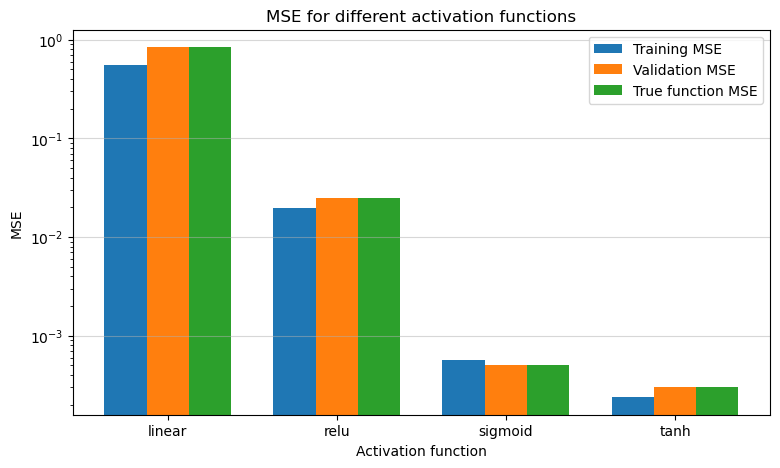

In [24]:
plot_mse_categorical(activation_data, "activation", "Activation function", "MSE for different activation functions", log_y=True)

**Figure 2.** Comparison of the MSE evaluated on the training set, the validation set, and with respect to the true function for different activation functions. The linear activation function gives the poorest performance, with a validation MSE of approximately $8.41\times10^{-1}$, since a purely linear model cannot reproduce the non-linear behaviour of the third-order polynomial. The ReLU activation significantly improves the fit, reducing the validation MSE to approximately $2.51\times10^{-2}$. The sigmoid and tanh activation functions provide substantially better approximations, with validation MSEs of $5.07\times10^{-4}$ and $3.02\times10^{-4}$, respectively. Among the tested activation functions, tanh gives the lowest validation and true-function MSE, indicating the most accurate approximation of the polynomial under the chosen training conditions.

In [25]:
optimizer_values = ["sgd", "adam"]
activation = "tanh"

In [26]:
optimizer_results = []

for optimizer in optimizer_values:

    model_poly = build_model_poly(n_neurons=n_neurons, activation=activation, optimizer=optimizer)

    model_poly, history_poly, results_poly = run_experiment_poly(model_poly, x_train_poly, y_train_poly, x_valid_poly, y_valid_poly, y_target_poly, N_epochs_poly, batch_size_poly)

    optimizer_results.append({"optimizer": optimizer, "MSE_train": results_poly["MSE_train"], "MSE_valid": results_poly["MSE_valid"], "MSE_true": results_poly["MSE_true"]})

    print(
        f"optimizer: {optimizer:7s} | "
        f"MSE train: {results_poly['MSE_train']:.6e} | "
        f"MSE valid: {results_poly['MSE_valid']:.6e} | "
        f"MSE true: {results_poly['MSE_true']:.6e}"
    )

optimizer: sgd     | MSE train: 1.262738e-03 | MSE valid: 9.992165e-04 | MSE true: 9.992165e-04
optimizer: adam    | MSE train: 1.892614e-04 | MSE valid: 2.525575e-04 | MSE true: 2.525575e-04


In [27]:
optimizer_data = pd.DataFrame(optimizer_results)

optimizer_data

,optimizer,MSE_train,MSE_valid,MSE_true
0,sgd,0.001263,0.000999,0.000999
1,adam,0.000189,0.000253,0.000253


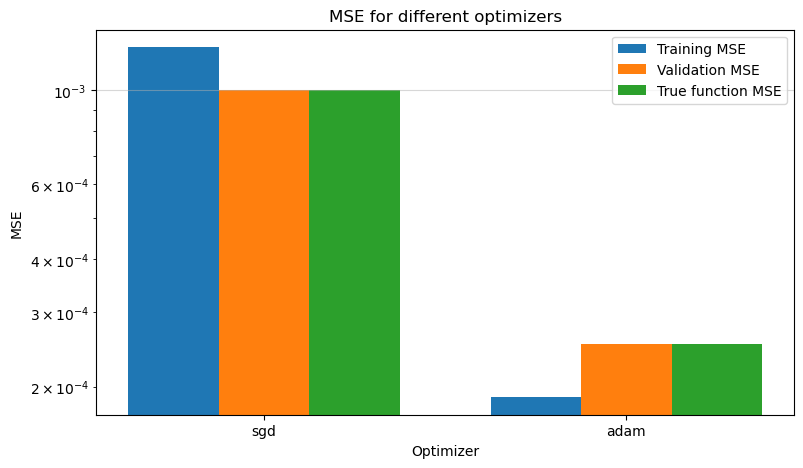

In [28]:
plot_mse_categorical(optimizer_data, "optimizer", "Optimizer", "MSE for different optimizers", log_y=True)

**Figure 3.** Comparison of the MSE evaluated on the training set, the validation set, and with respect to the true function for the SGD and Adam optimizers. The Adam optimizer provides a better fit than SGD, with a validation and true-function MSE of approximately $2.53\times10^{-4}$ compared with $9.99\times10^{-4}$ obtained with SGD. The training MSE is also lower for Adam, decreasing from $1.26\times10^{-3}$ with SGD to $1.89\times10^{-4}$. These results indicate that, for this regression problem and the chosen network architecture, Adam is more effective than SGD in optimizing the network parameters and reproducing the underlying polynomial.

In [29]:
loss_values = ["mse", "mae"]

loss_results = []

for loss in loss_values:

    model_poly = build_model_poly(
        n_neurons=n_neurons,
        activation=activation,
        optimizer=optimizer,
        loss=loss
    )

    model_poly, history_poly, results_poly = run_experiment_poly(
        model_poly,
        x_train_poly,
        y_train_poly,
        x_valid_poly,
        y_valid_poly,
        y_target_poly,
        N_epochs_poly,
        batch_size_poly
    )

    loss_results.append({
        "loss": loss,
        "MSE_train": results_poly["MSE_train"],
        "MSE_valid": results_poly["MSE_valid"],
        "MSE_true": results_poly["MSE_true"]
    })

    print(
        f"loss: {loss:4s} | "
        f"MSE train: {results_poly['MSE_train']:.6e} | "
        f"MSE valid: {results_poly['MSE_valid']:.6e} | "
        f"MSE true: {results_poly['MSE_true']:.6e}"
    )

loss: mse  | MSE train: 8.974642e-05 | MSE valid: 1.250794e-04 | MSE true: 1.250794e-04
loss: mae  | MSE train: 1.403801e-03 | MSE valid: 2.939318e-03 | MSE true: 2.939318e-03


In [30]:
loss_data= pd.DataFrame(loss_results)

loss_data

,loss,MSE_train,MSE_valid,MSE_true
0,mse,0.000090,0.000125,0.000125
1,mae,0.001404,0.002939,0.002939


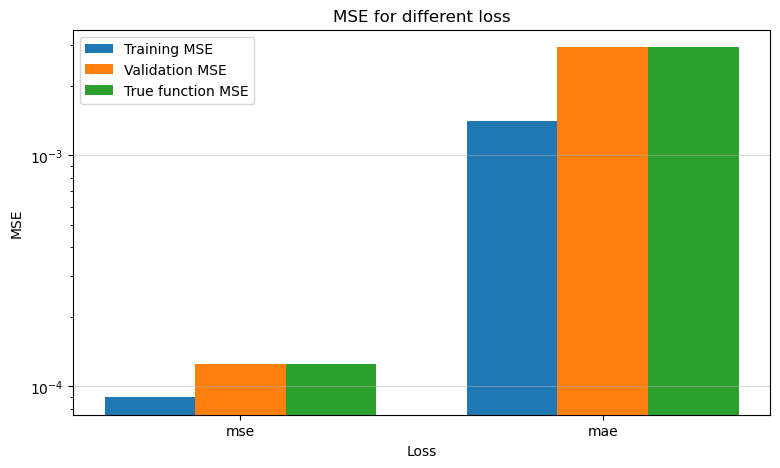

In [31]:
plot_mse_categorical(loss_data, "loss", "Loss", "MSE for different loss", log_y=True)

**Figure 4.** Comparison of the MSE evaluated on the training set, the validation set, and with respect to the true function for the MSE and MAE loss functions. The MSE loss provides a significantly better fit than the MAE loss. In particular, the validation and true-function MSE are approximately $1.25\times10^{-4}$ when using MSE, compared with $2.94\times10^{-3}$ obtained with MAE. The training MSE is also considerably lower for MSE, decreasing from $1.40\times10^{-3}$ with MAE to $8.97\times10^{-5}$ with MSE. These results indicate that, for this regression problem, the MSE loss is more effective at optimizing the network parameters and reproducing the underlying polynomial accurately.

In [32]:
#Final model parameters after finding best configuration

N_train_poly = 500
N_valid_poly = 50

sigma_poly = 0.2

N_epochs_poly = 2000
batch_size_poly = 32

n_neurons_poly = 10
activation_poly = "tanh"
optimizer_poly = "adam"
loss="mse"

In [33]:
x_train_poly, y_train_poly, x_valid_poly, y_valid_poly, y_target_poly = generate_data_poly(
    N_train_poly,
    N_valid_poly,
    sigma_poly
)

In [34]:
model_poly = build_model_poly(
    n_neurons=n_neurons_poly,
    activation=activation_poly,
    optimizer=optimizer_poly
)

model_poly, history_poly, results_poly = run_experiment_poly(
    model_poly,
    x_train_poly,
    y_train_poly,
    x_valid_poly,
    y_valid_poly,
    y_target_poly,
    N_epochs_poly,
    batch_size_poly
)

print(f"MSE train : {results_poly['MSE_train']:.6e}")
print(f"MSE valid : {results_poly['MSE_valid']:.6e}")
print(f"MSE true  : {results_poly['MSE_true']:.6e}")

MSE train : 3.917764e-02
MSE valid : 3.887822e-02
MSE true  : 2.226334e-03


In [35]:
def plot_poly_fit(model, x_train, y_train, x_valid, y_valid):

    x_plot = np.linspace(-1, 1, 500)
    y_true = f(x_plot)

    y_pred = model.predict(x_plot, verbose=0).flatten()

    plt.figure(figsize=(9, 5))

    plt.scatter(x_train, y_train, s=15, alpha=0.4, label="Training data")
    plt.scatter(x_valid, y_valid, s=30, label="Validation data")

    plt.plot(x_plot, y_true, label="True function")
    plt.plot(x_plot, y_pred, "--", label="NN prediction")

    plt.xlabel("$x$")
    plt.ylabel("$f(x)$")
    plt.title("Polynomial fit with noisy data")

    plt.grid(True)
    plt.legend()

    plt.show()

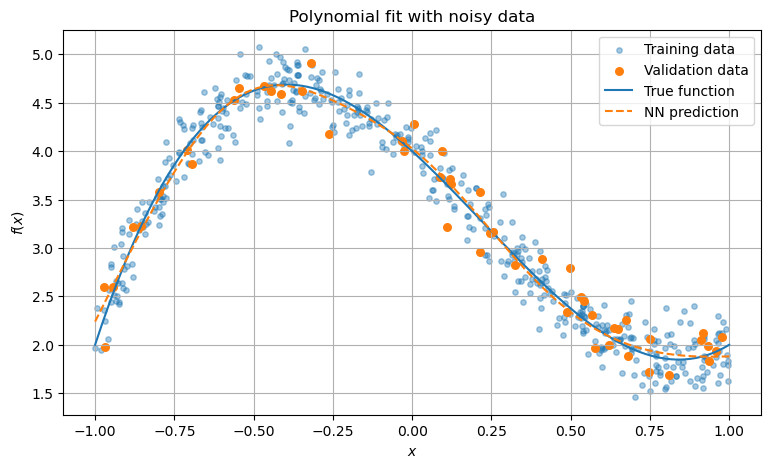

In [36]:
plot_poly_fit(
    model_poly,
    x_train_poly,
    y_train_poly,
    x_valid_poly,
    y_valid_poly
)

**Figure 5.** Comparison between the training and validation data, the true polynomial function, and the prediction of the neural network. The model is trained using $N_{\mathrm{train}}=500$ data points with noise level $\sigma=0.2$, for $N_{\mathrm{epochs}}=2000$ epochs, with $10$ neurons in the hidden layer, a hyperbolic tangent activation function, the Adam optimizer, and the MSE loss function. The neural network prediction closely follows the true function throughout the training interval $x\in[-1,1]$, despite the presence of noise in the training data. The good agreement between the predicted and true curves, together with the consistent distribution of the training and validation points around the underlying function, demonstrates that the selected configuration provides an accurate fit of the third-order polynomial.

In [37]:
#Prediction out of range

x_test_out = np.linspace(-2, 2, 500)

y_true_out = f(x_test_out)
y_pred_out = model_poly.predict(x_test_out, verbose=0).flatten()

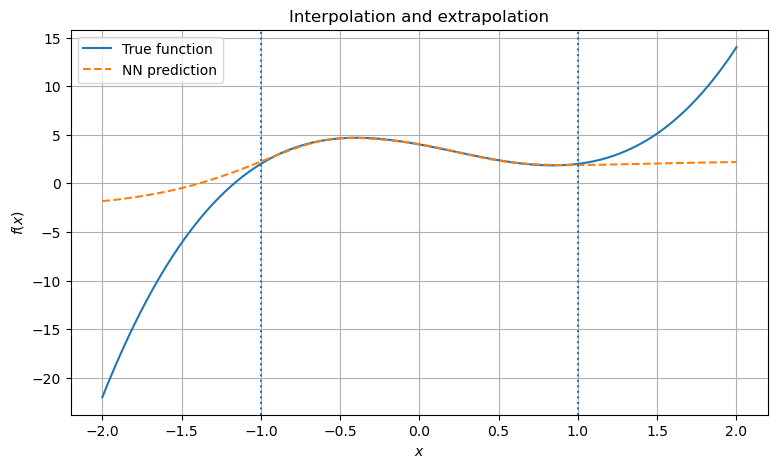

In [38]:
plt.figure(figsize=(9, 5))

plt.plot(x_test_out, y_true_out, label="True function")
plt.plot(x_test_out, y_pred_out, "--", label="NN prediction")

plt.axvline(-1, linestyle=":")
plt.axvline(1, linestyle=":")

plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.title("Interpolation and extrapolation")

plt.grid(True)
plt.legend()

plt.show()

### Interpolation and extrapolation

The neural network is able to accurately reproduce the target function within the training interval $[-1,1]$. However, outside this interval the prediction rapidly deviates from the true polynomial and tends to an almost constant value.

This result highlights an important distinction between **interpolation** and **extrapolation**: a neural network can accurately learn a function within the domain covered by the training data without necessarily learning its analytical form or being able to extrapolate it correctly outside that domain.